In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df  = pd.read_csv("countrywise sugarcane production.csv")

In [3]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


## Data cleaning


In [5]:
df["Production (Tons)"] =df["Production (Tons)"].str.replace("." , "")
df["Production per Person (Kg)"] =df["Production per Person (Kg)"].str.replace(".","").str.replace(",",".")
df["Acreage (Hectare)"] =df["Acreage (Hectare)"].str.replace("." , "")
df["Yield (Kg / Hectare)"] =df["Yield (Kg / Hectare)"].str.replace("." , "").str.replace(",",".")

In [6]:
df.head(5)

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [7]:
df.rename(columns  = {"Production (Tons)": "Production(Tons)"},inplace = True)
df.rename(columns  = {"Production per Person (Kg)": "Production_per_person(Kg)"},inplace = True)
df.rename(columns  = {"Acreage (Hectare)": "Acreage(Hectare)"},inplace = True)
df.rename(columns  = {"Yield (Kg / Hectare)": "Yield(Kg/Hectare)"},inplace = True)

In [8]:
df.head()

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [9]:
df.isna().sum()

Unnamed: 0                   0
Country                      0
Continent                    0
Production(Tons)             0
Production_per_person(Kg)    0
Acreage(Hectare)             1
Yield(Kg/Hectare)            1
dtype: int64

In [10]:
df[df["Acreage(Hectare)"].isnull()]

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
99,99,Djibouti,Africa,53,51,NaN,NaN


In [11]:
df = df.dropna().reset_index()
df.head()

,index,Unnamed: 0,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [12]:
df.drop(["Production_per_Person (Kg)"],axis = 1,inplace = True)

KeyError: "['Production_per_Person (Kg)'] not found in axis"

In [27]:
df.head()

,index,Unnamed: 0,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [29]:
df.dtypes

index                         int64
Unnamed: 0                    int64
Country                      object
Continent                    object
Production(Tons)             object
Production_per_person(Kg)    object
Acreage(Hectare)             object
Yield(Kg/Hectare)            object
dtype: object

In [31]:
df["Production(Tons)"] =df["Production(Tons)"].astype(float)
df["Production_per_person(Kg)"] =df["Production_per_person(Kg)"].astype(float)
df["Acreage(Hectare)"] =df["Acreage(Hectare)"].astype(float)
df["Yield(Kg/Hectare)"] =df["Yield(Kg/Hectare)"].astype(float)

In [33]:
df.dtypes

index                          int64
Unnamed: 0                     int64
Country                       object
Continent                     object
Production(Tons)             float64
Production_per_person(Kg)    float64
Acreage(Hectare)             float64
Yield(Kg/Hectare)            float64
dtype: object

In [35]:
df.nunique()

index                        102
Unnamed: 0                   102
Country                      102
Continent                      6
Production(Tons)             102
Production_per_person(Kg)    101
Acreage(Hectare)             101
Yield(Kg/Hectare)            102
dtype: int64

## Univariate Analysis

In [37]:
df.head()

,index,Unnamed: 0,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,1,1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,2,2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,3,3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,4,4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


### How many countries produce sugarcane from each continent?

In [39]:
df["Continent"].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

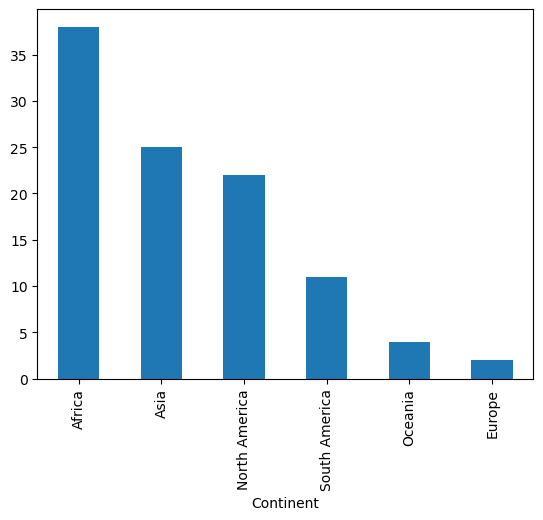

In [41]:
df["Continent"].value_counts().plot(kind = "bar")

C:\Users\KIIT\AppData\Local\Temp\ipykernel_27832\707082110.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production(Tons)"])
C:\Users\KIIT\AppData\Local\Temp\ipykernel_27832\707082110.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production_per_person(Kg)"])
C:\Users\KIIT\App

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Density'>

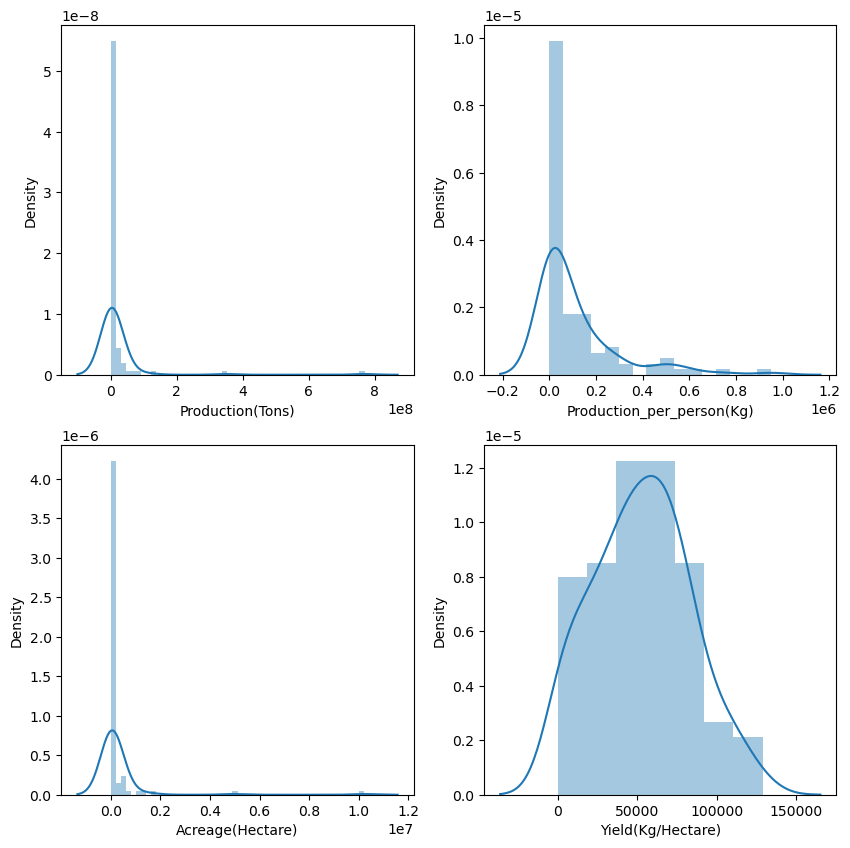

In [43]:
plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
sns.distplot(df["Production(Tons)"])
plt.subplot(2,2,2)
sns.distplot(df["Production_per_person(Kg)"])
plt.subplot(2,2,3)
sns.distplot(df["Acreage(Hectare)"])
plt.subplot(2,2,4)
sns.distplot(df["Yield(Kg/Hectare)"])

<Axes: ylabel='Yield(Kg/Hectare)'>

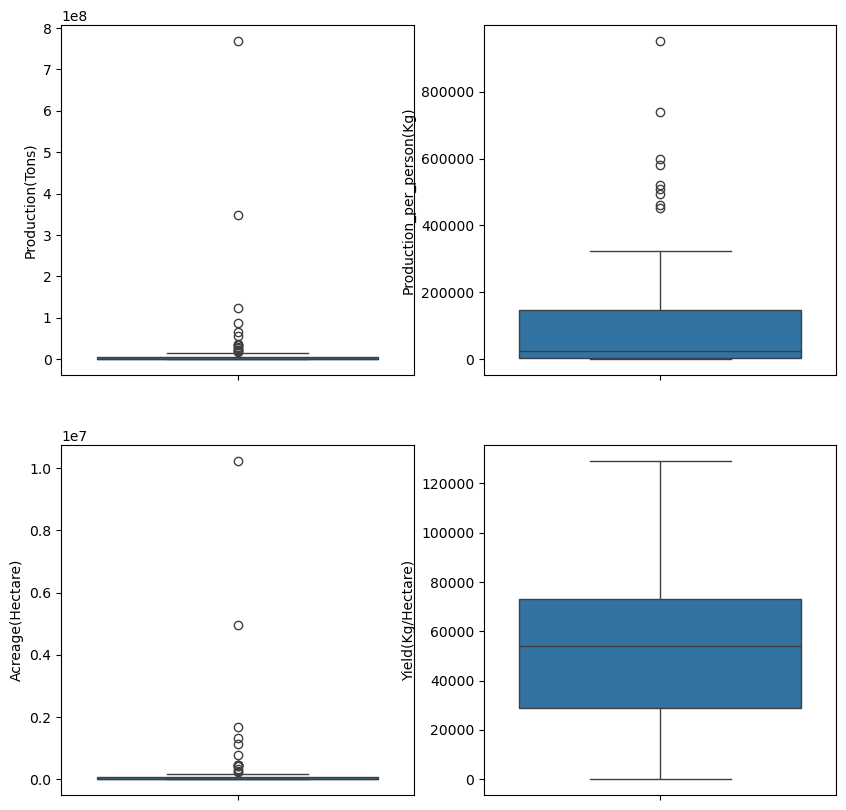

In [45]:
plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
sns.boxplot(df["Production(Tons)"])
plt.subplot(2,2,2)
sns.boxplot(df["Production_per_person(Kg)"])
plt.subplot(2,2,3)
sns.boxplot(df["Acreage(Hectare)"])
plt.subplot(2,2,4)
sns.boxplot(df["Yield(Kg/Hectare)"])

In [47]:
df.describe()

,index,Unnamed: 0,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
count,102.000000,102.000000,1.020000e+02,102.000000,1.020000e+02,102.000000
mean,50.529412,50.529412,1.850372e+07,112952.435755,2.498981e+05,52628.078431
std,29.638985,29.638985,8.419149e+07,176651.341929,1.137003e+06,30504.676683
min,0.000000,0.000000,1.000000e+00,0.000000,0.000000e+00,10.000000
25%,25.250000,25.250000,6.251875e+04,3671.910000,1.104000e+03,29072.025000
50%,50.500000,50.500000,1.440044e+06,25572.500000,1.655800e+04,54108.950000
75%,75.750000,75.750000,6.426824e+06,146384.750000,8.047400e+04,73282.700000
max,102.000000,102.000000,7.686784e+08,951087.000000,1.022620e+07,129049.300000


### Bivariate analysis

#### Which country produced maximum sugarcane?

In [49]:
df_new = df[["Country","Production(Tons)"]].set_index("Country")

In [51]:
df_new

,Production(Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0
...,...
Spain,394.0
Lebanon,97.0
Singapore,50.0


#### Percentage

In [53]:
df_new["Production(Tons)_percent"] = df_new["Production(Tons)"]*100/df_new["Production(Tons)"].sum()

In [55]:
df_new

,Production(Tons),Production(Tons)_percent
Country,,
Brazil,768678382.0,4.072729e+01
India,348448000.0,1.846200e+01
China,123059739.0,6.520138e+00
Thailand,87468496.0,4.634389e+00
Pakistan,65450704.0,3.467809e+00
...,...,...
Spain,394.0,2.087551e-05
Lebanon,97.0,5.139401e-06
Singapore,50.0,2.649176e-06


<Axes: ylabel='Production(Tons)_percent'>

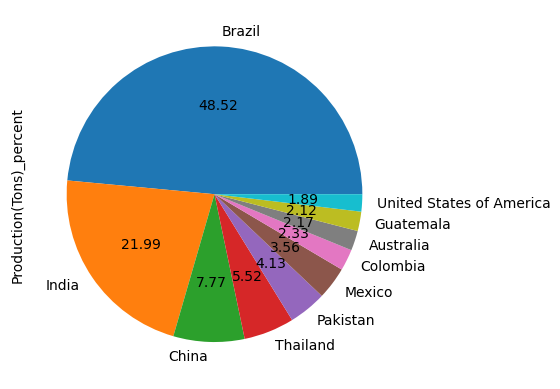

In [57]:
df_new["Production(Tons)_percent"].head(10).plot(kind = "pie",autopct = "%.2f")

<Axes: xlabel='Country'>

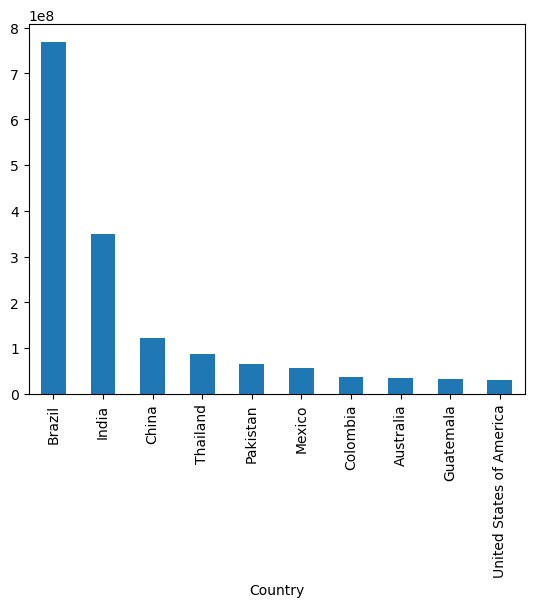

In [59]:
df_new["Production(Tons)"].head(10).plot(kind = "bar")

C:\Users\KIIT\AppData\Local\Temp\ipykernel_27832\4163944591.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


[Text(0, 0, 'Brazil'),
 Text(1, 0, 'India'),
 Text(2, 0, 'China'),
 Text(3, 0, 'Thailand'),
 Text(4, 0, 'Pakistan'),
 Text(5, 0, 'Mexico'),
 Text(6, 0, 'Colombia'),
 Text(7, 0, 'Australia'),
 Text(8, 0, 'Guatemala'),
 Text(9, 0, 'United States of America')]

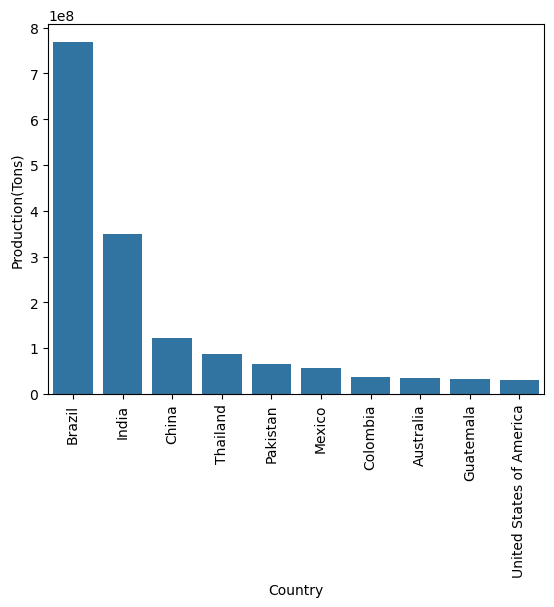

In [61]:
ax = sns.barplot(data = df.head(10),x = "Country",y = "Production(Tons)")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)

### Which country has highest land?

C:\Users\KIIT\AppData\Local\Temp\ipykernel_27832\2472224648.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


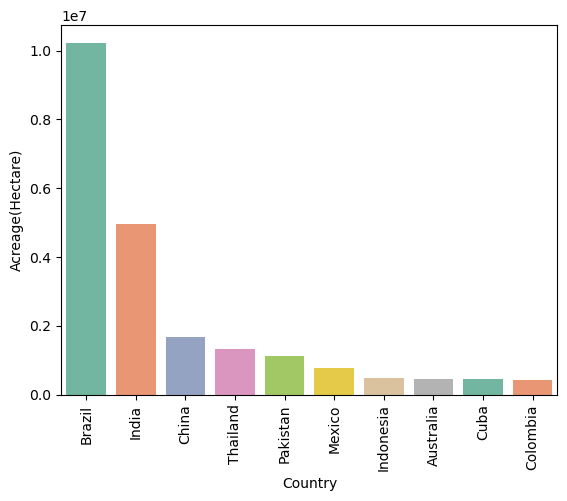

In [63]:
df_acr = df.sort_values("Acreage(Hectare)",ascending = False)
ax = sns.barplot(data = df_acr.head(10), x = "Country", y = "Acreage(Hectare)",hue = "Country",palette = "Set2")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()


### Highest yield

C:\Users\KIIT\AppData\Local\Temp\ipykernel_27832\347986008.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


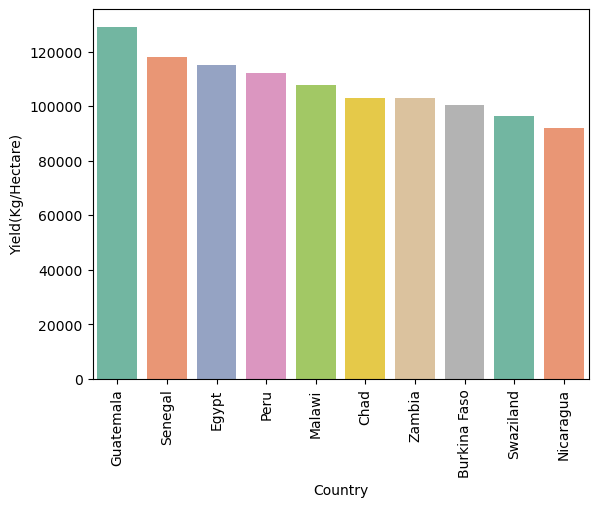

In [65]:
df_yield = df.sort_values("Yield(Kg/Hectare)",ascending = False)
ax = sns.barplot(data = df_yield.head(10), x = "Country", y = "Yield(Kg/Hectare)",hue = "Country",palette = "Set2")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()


### Correlation

In [67]:
df.select_dtypes(include='float64').corr()


,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Production(Tons),1.000000,0.015000,0.997550,0.132812
Production_per_person(Kg),0.015000,1.000000,0.012557,0.017999
Acreage(Hectare),0.997550,0.012557,1.000000,0.113433
Yield(Kg/Hectare),0.132812,0.017999,0.113433,1.000000


<Axes: >

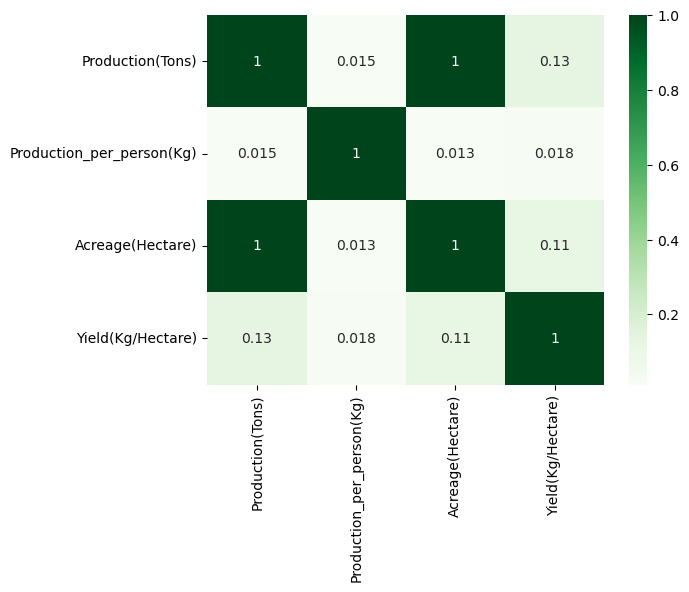

In [69]:
sns.heatmap(df.select_dtypes(include='float64').corr(),annot = True,cmap="Greens")

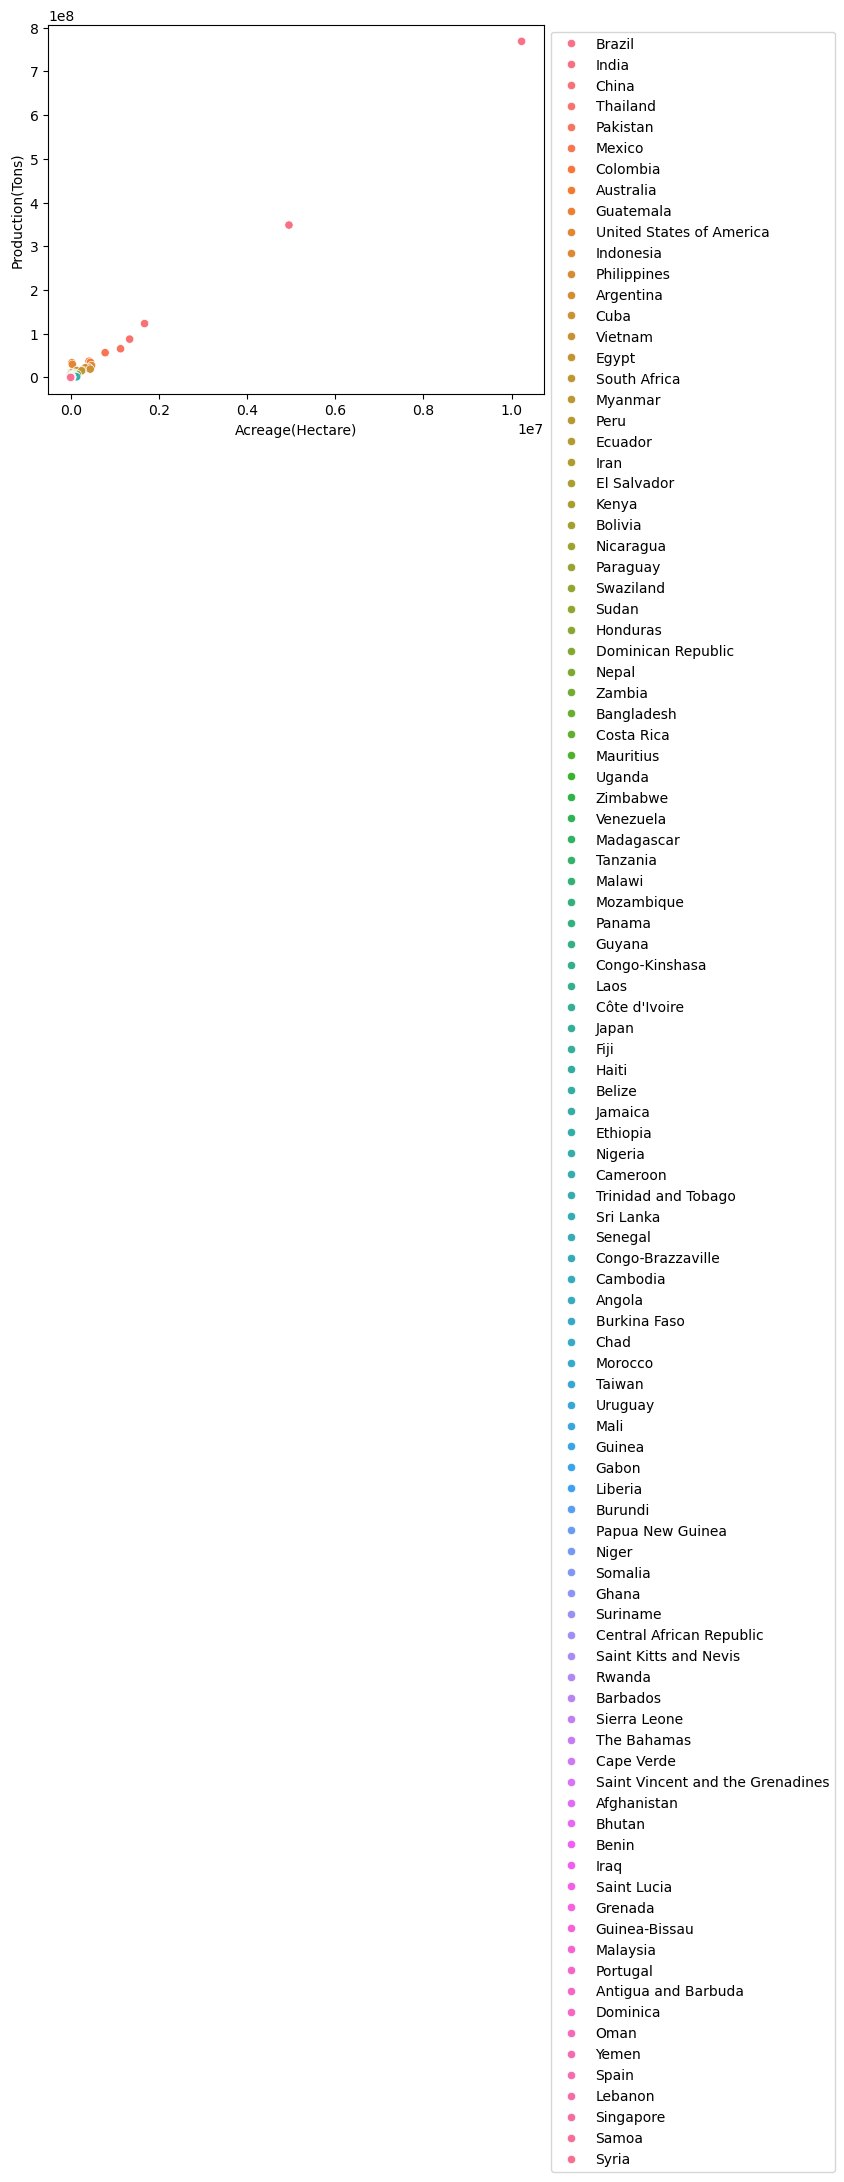

In [71]:

sns.scatterplot(data = df,x = "Acreage(Hectare)",y = "Production(Tons)",hue = "Country")
plt.legend(loc = "upper left",bbox_to_anchor=(1,1))

### Analysis for Continent

In [73]:
df_continent = df.groupby("Continent").sum()

In [75]:
df_continent

,index,Unnamed: 0,Country,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Continent,,,,,,,
Africa,2061,2061,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681472.0,2332636.293,1439089.0,2142107.5
Asia,1253,1253,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425.0,1857769.303,10608319.0,1171871.4
Europe,189,189,PortugalSpain,5823.0,536.000,71.0,131870.9
North America,1101,1101,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947.0,3796081.508,1581983.0,1082602.4
Oceania,227,227,AustraliaFijiPapua New GuineaSamoa,36177574.0,28593.605,490909.0,162419.1
South America,323,323,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126.0,3505531.738,11369236.0,677192.7


### Which continent produces maximum sugarcane?

In [77]:
df["Continent"].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

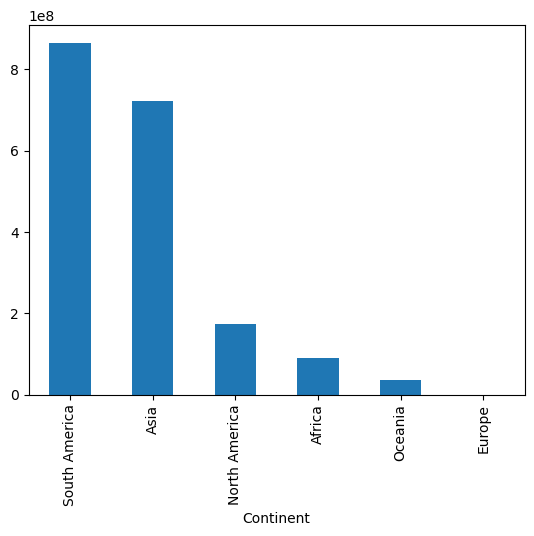

In [79]:
df_continent["Production(Tons)"].sort_values(ascending = False).plot(kind = "bar")

<Axes: xlabel='Continent'>

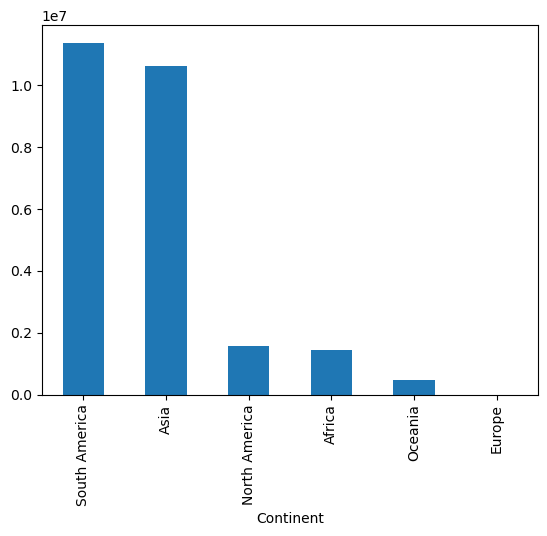

In [81]:
df_continent["Acreage(Hectare)"].sort_values(ascending = False).plot(kind = "bar")

### Do number of countries in a continent effect production of sugarcane?

In [83]:
df_continent["number_of_countries"] = df.groupby("Continent").count()["Country"]

NameError: name 'continent_names' is not defined

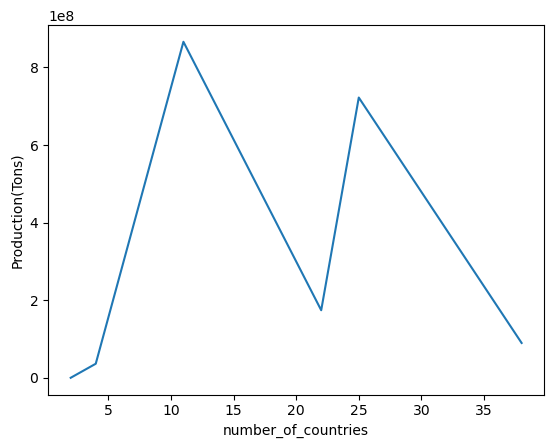

In [85]:
continent_name = df_continent.index.to_list()
sns.lineplot(data = df_continent, x = "number_of_countries", y = "Production(Tons)")
plt.xticks(df_continent["number_of_countries"],continent_names,rotation -50)
plt.show()


### Production distribution by Continent

<Axes: ylabel='Production(Tons)'>

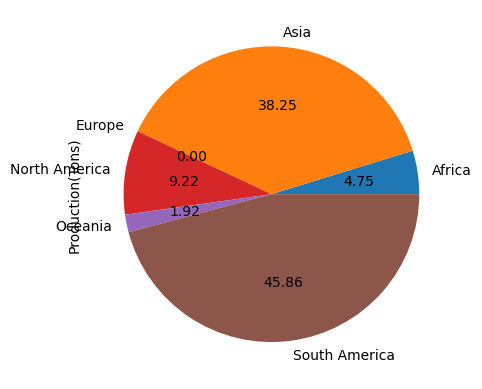

In [87]:
df_continent["Production(Tons)"].plot(kind = "pie",autopct = "%.2f")